## Setup

In [1]:
## imports
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


## Data

In [2]:
datapath = "./data"
cross_all = pd.read_csv(f"{datapath}/crossreactivity_enFoldX_features.csv")

In [3]:
cross_best_model = cross_all.groupby(['tcr','epitope']).af3_ranking.max().reset_index()
cross_best = cross_all.merge(cross_best_model, on=['tcr','epitope','af3_ranking'])

In [4]:
nonfeature_cols = ['af3_seed','af3_sample','af3_ranking','tcr', 'epitope', 'HLA', 'label', 'WT_Epitope', 'mut_pos']
feature_cols = [x for x in cross_all.columns if x not in nonfeature_cols]

In [5]:
## prepare ensemble data: mean + standard deviation of all feature columns for each tcr/epitope pair
groupcols=['tcr','epitope','label']
data_mean = cross_all[feature_cols +groupcols].groupby(groupcols).mean().reset_index() 
data_std = cross_all[feature_cols +groupcols].groupby(groupcols).std().reset_index()
data_ensemble = data_mean.merge(data_std, on=groupcols, suffixes=["","_std"])
ensemble_cols = feature_cols + [x+"_std" for x in feature_cols]

In [6]:
len(cross_all), len(cross_best), len(data_ensemble)

(30100, 1204, 1204)

## Train + predict: cross-reactivity

In [7]:
def kfold_and_regression(data, cols, C=1., random_state=42):
    scaler = StandardScaler().set_output(transform="pandas")
    X_scaled = scaler.fit_transform(data[cols])
    y = data.label         
    mean_fpr = np.linspace(0, 1, 100)  # For interpolation

    model = LogisticRegression(penalty='l2', C=C,  solver='liblinear', max_iter=1000) ## this can be changed to other regression models
        
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    aucs, tprs, yprobas = [], [], []
    for i, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))  # Interpolate to common FPR points for mean curve
        yprobas.append(y_proba)

    return aucs, tprs, yprobas

def plot_ROCs(tprs, aucs, title='', figsize=(7,7)):    
    mean_fpr = np.linspace(0, 1, 100)  # For interpolation
    fig, ax = plt.subplots(figsize=figsize)

    for name in tprs.keys():
        mean_tpr = np.mean(tprs[name], axis=0)
        mean_auc = auc(mean_fpr, mean_tpr)
        std_auc = np.std(aucs[name])
        
        # Compute 95% CI for TPR at each FPR point
        tprs_lower = np.percentile(tprs[name], 2.5, axis=0)
        tprs_upper = np.percentile(tprs[name], 97.5, axis=0)

        conf_interval = 1.96*std_auc/np.sqrt(len(aucs[name]))
        ax.plot(mean_fpr, mean_tpr, lw=2, label=f'{name}: AUC={mean_auc:.2f} [95% CI: ± {1.96*std_auc/np.sqrt(len(aucs[name])):.2f}]')
        ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.04) ## shaded conf interval
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.legend(frameon=False)
    sns.despine()
    plt.show()

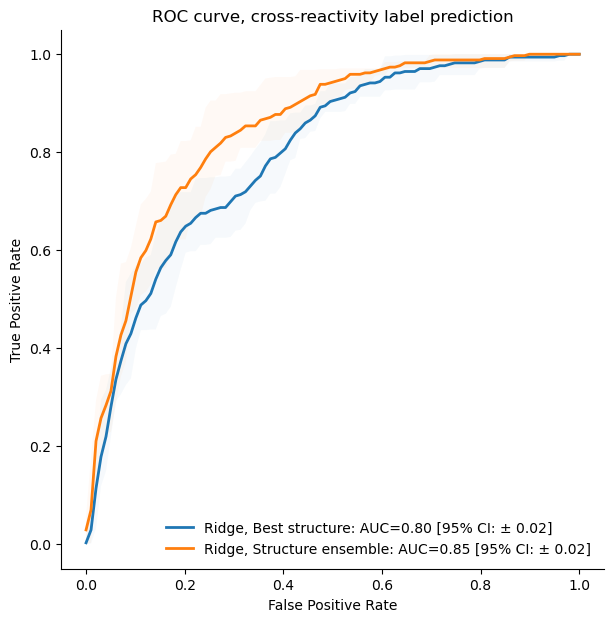

In [8]:
C = 10
random_state=25
aucs_beststruct, tprs_beststruct, y_proba_beststruct = kfold_and_regression(cross_best, feature_cols, C, random_state)
aucs_ensemble, tprs_ensemble, y_proba_ensemble = kfold_and_regression(data_ensemble, ensemble_cols, C, random_state)

all_aucs, all_tprs, = {}, {}
all_aucs['Ridge, Best structure'] = aucs_beststruct
all_aucs['Ridge, Structure ensemble'] = aucs_ensemble
all_tprs['Ridge, Best structure'] = tprs_beststruct
all_tprs['Ridge, Structure ensemble'] = tprs_ensemble

plot_ROCs(all_tprs, all_aucs, title='ROC curve, cross-reactivity label prediction')